# Customer Segmentation using RFM Analysis and K-Means Clustering

## Objective

The objective of this project is to segment retail customers based on their purchasing behavior using RFM Analysis and K-Means Clustering. This helps businesses identify valuable customers and create targeted marketing strategies.

---

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

---

## Dataset

Online Retail Dataset (UCI / Kaggle)

---

## Workflow

1. Import Libraries
2. Load Dataset
3. Data Inspection
4. Data Cleaning
5. Feature Engineering
6. RFM Analysis
7. Data Scaling
8. K-Means Clustering
9. Customer Profiling
10. Business Insights

In [122]:
# ==========================================
# Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

print("All libraries imported successfully!")

All libraries imported successfully!


# Load the Dataset

In this step, we load the Online Retail dataset into a Pandas DataFrame to begin our analysis.

In [123]:
# ==========================================
# Load the Dataset
# ==========================================

# Read the CSV file
df = pd.read_csv("OnlineRetail.csv", encoding="ISO-8859-1")

# Display the first 5 rows
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


# Data Inspection

Before cleaning the data, we inspect its structure, data types, missing values, and basic statistics.

In [124]:
# Shape of the dataset
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Data types
print("\nData Types:")
print(df.dtypes)

Dataset Shape: (541909, 8)

Columns:
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

Data Types:
InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object


Check Missing Values

In [125]:
# ============================================
# Missing Values
# ============================================

print("Missing Values:")
print(df.isnull().sum())

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


Check Duplicate Records

In [126]:
# ============================================
# Duplicate Rows
# ============================================

duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)


Duplicate Rows: 5268


Dataset Statistics

In [127]:
# ============================================
# Statistical Summary
# ============================================

df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


Dataset Information

In [128]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


Convert Invoice Date

In [129]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

Create Total Amount

In [130]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


Remove Cancelled Orders

In [131]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

Remove Negative Quantity

In [132]:
df = df[df['Quantity'] > 0]

Remove Negative Price

In [133]:
df = df[df['UnitPrice'] > 0]

Check New Shape

In [134]:
print(df.shape)

(530104, 9)


# RFM Analysis

## Find Reference Date

In [135]:

# Latest purchase date

print(df['InvoiceDate'].max())

2011-12-09 12:50:00


Create Reference Date

In [136]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print(snapshot_date)

2011-12-10 12:50:00


Create the RFM Table

In [137]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


Check RFM Shape

In [138]:
print(rfm.shape)

(4338, 3)


Check Statistics

In [139]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


## Distribution of Recency

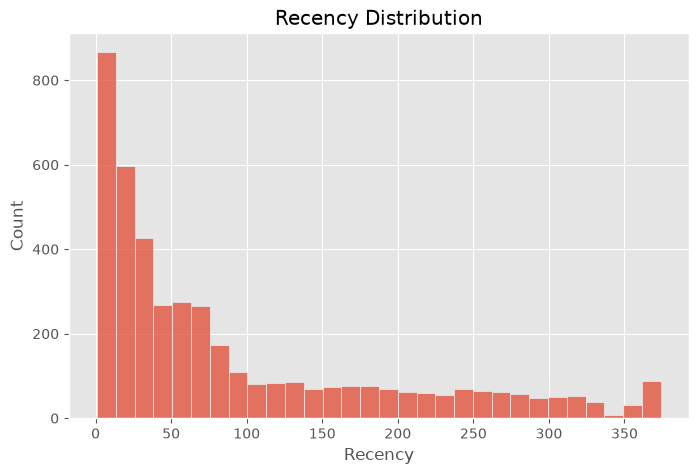

In [140]:
plt.figure(figsize=(8,5))

sns.histplot(rfm['Recency'], bins=30)

plt.title("Recency Distribution")

plt.show()

Distribution of Frequency

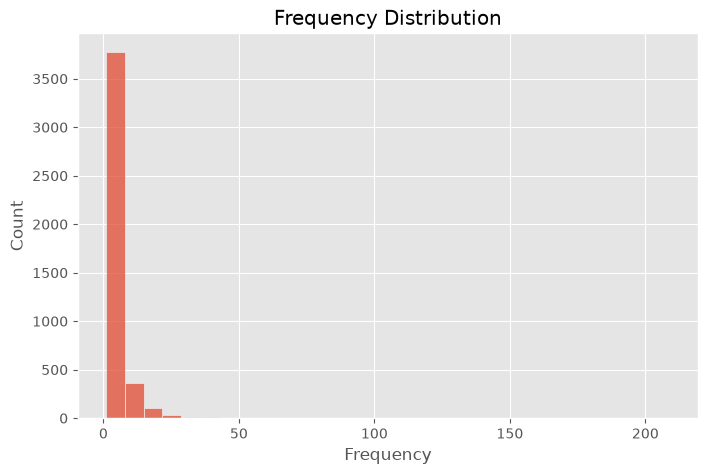

In [141]:
plt.figure(figsize=(8,5))

sns.histplot(rfm['Frequency'], bins=30)

plt.title("Frequency Distribution")

plt.show()

Distribution of Monetary

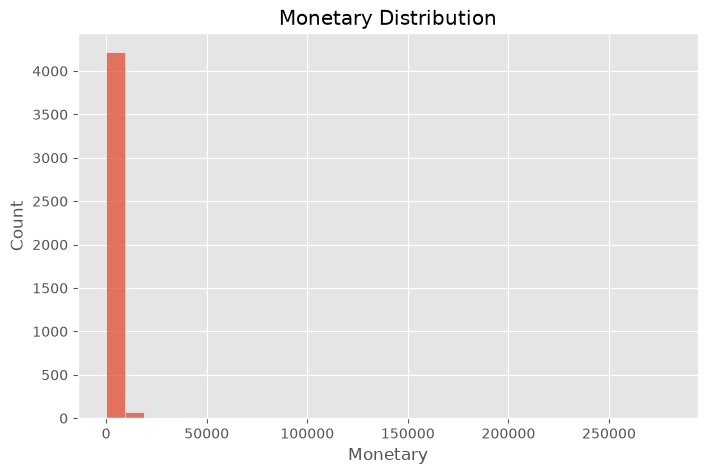

In [142]:
plt.figure(figsize=(8,5))

sns.histplot(rfm['Monetary'], bins=30)

plt.title("Monetary Distribution")

plt.show()

# Data Scaling

The RFM values are scaled using StandardScaler before applying K-Means clustering. Scaling ensures that all variables contribute equally to the clustering process.

In [143]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

print(rfm_scaled[:5])

[[ 2.33457414 -0.4250965   8.35866818]
 [-0.90534032  0.3544168   0.25096626]
 [-0.17535959 -0.03533985 -0.02859601]
 [-0.73534481 -0.4250965  -0.0330118 ]
 [ 2.17457836 -0.4250965  -0.19134727]]


Check Shape

In [144]:
print(rfm_scaled.shape)

(4338, 3)


# Elbow Method

The Elbow Method is used to determine the optimal number of clusters for K-Means clustering.

In [145]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

Plot Elbow Curve

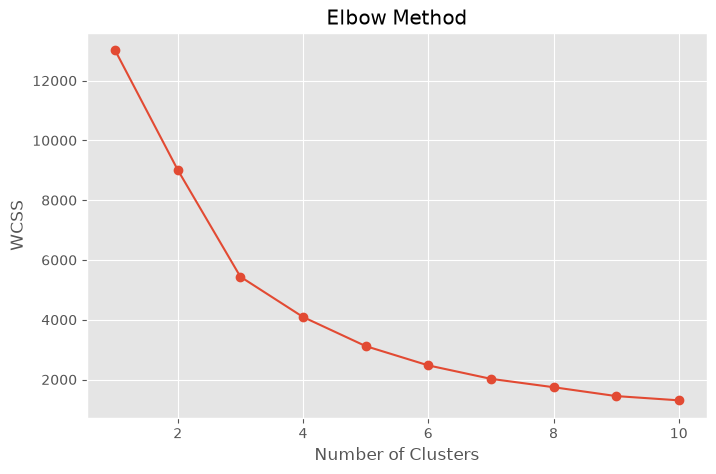

In [146]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

Apply K-Means

In [147]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

Check Clusters

In [148]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


Cluster Count

In [149]:
rfm['Cluster'].value_counts()

Cluster
0    3054
1    1067
3     204
2      13
Name: count, dtype: int64

Visualize Clusters

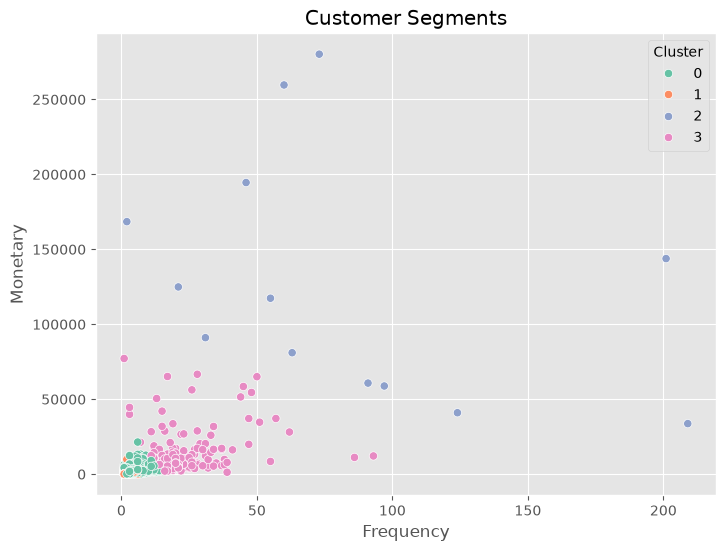

In [150]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='Set2'
)

plt.title("Customer Segments")

plt.show()

Cluster Profile

In [151]:
cluster_summary = rfm.groupby('Cluster').mean()

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,43.702685,3.682711,1359.049284
1,248.075914,1.552015,480.617480
2,7.384615,82.538462,127338.313846
3,15.500000,22.333333,12709.090490


# Business Insights

Cluster 0:
- Loyal customers
- High purchase frequency
- Good revenue contribution

Cluster 1:
- Lost customers
- Long time since last purchase
- Low spending

Cluster 2:
- Regular customers
- Moderate spending
- Opportunity for upselling

Cluster 3:
- VIP customers
- Highest spending
- Highest purchase frequency
- Retain using loyalty programs